**Nama : Upi Wiraningsih**

**Nim : F1G123054**

**Kelas : C**

 **Judul : Prediksi Konsumsi Energi Rumah Tangga Menggunakan Data Smart Meter**


**1. IMPORT LIBRARY**

Pada tahap ini dilakukan proses import berbagai library yang digunakan dalam penelitian. Library pandas digunakan untuk membaca dan mengolah data dalam bentuk DataFrame, sedangkan numpy digunakan untuk operasi numerik.

Library matplotlib.pyplot dan seaborn digunakan untuk visualisasi data seperti distribusi, heatmap, dan boxplot, yang bertujuan untuk memahami pola data.

Selain itu, digunakan library dari Scikit-Learn (sklearn) untuk keperluan machine learning, seperti train_test_split untuk membagi data serta GridSearchCV untuk melakukan optimasi parameter model.

Model yang digunakan dalam penelitian ini meliputi Random Forest, Extra Trees, dan Gradient Boosting.

In [31]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

## **1. DATA UNDERSTANDING**

In [32]:
df = pd.read_csv("smart_meter_data.csv")
print(df.head(10))

             Timestamp  Electricity_Consumed  Temperature  Humidity  \
0  2024-01-01 00:00:00              0.457786     0.469524  0.396368   
1  2024-01-01 00:30:00              0.351956     0.465545  0.451184   
2  2024-01-01 01:00:00              0.482948     0.285415  0.408289   
3  2024-01-01 01:30:00              0.628838     0.482095  0.512308   
4  2024-01-01 02:00:00              0.335974     0.624741  0.672021   
5  2024-01-01 02:30:00              0.335977     0.355389  0.382767   
6  2024-01-01 03:00:00              0.638202     0.667102  0.643164   
7  2024-01-01 03:30:00              0.502906     0.591854  0.381205   
8  2024-01-01 04:00:00              0.296754     0.427858  0.371512   
9  2024-01-01 04:30:00              0.465427     0.507400  0.616383   

   Wind_Speed  Avg_Past_Consumption Anomaly_Label  
0    0.445441              0.692057        Normal  
1    0.458729              0.539874        Normal  
2    0.470360              0.614724        Normal  
3    0.576

### Membaca Dataset
Kode ini digunakan untuk membaca dataset yang berformat CSV menggunakan fungsi `read_csv()` dari library pandas.

Data yang telah dibaca kemudian ditampilkan sebanyak 10 baris pertama menggunakan `head(10)` untuk melihat gambaran awal dataset, seperti nama kolom, struktur data, dan contoh nilai pada setiap variabel.

Langkah ini dilakukan untuk memahami karakteristik awal data sebelum dilakukan proses preprocessing.

In [33]:
# Info data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB
None


### Informasi Dataset
Kode ini digunakan untuk menampilkan informasi umum mengenai dataset menggunakan fungsi `info()`.

Informasi yang ditampilkan meliputi jumlah data, nama kolom, tipe data setiap kolom, serta jumlah data yang tidak kosong.

Langkah ini penting untuk memastikan bahwa tipe data sudah sesuai dan untuk mendeteksi adanya missing value.

In [34]:
# Statistik deskriptif
print(df.describe())

       Electricity_Consumed  Temperature     Humidity   Wind_Speed  \
count           5000.000000  5000.000000  5000.000000  5000.000000   
mean               0.376677     0.525069     0.497632     0.464628   
std                0.164117     0.135603     0.146781     0.120370   
min                0.000000     0.000000     0.000000     0.000000   
25%                0.265349     0.434253     0.398956     0.382906   
50%                0.377244     0.524052     0.497539     0.464958   
75%                0.486002     0.617281     0.595359     0.547419   
max                1.000000     1.000000     1.000000     1.000000   

       Avg_Past_Consumption  
count           5000.000000  
mean               0.458738  
std                0.146749  
min                0.000000  
25%                0.358857  
50%                0.457814  
75%                0.555607  
max                1.000000  


### Statistik Deskriptif
Kode ini digunakan untuk menampilkan statistik deskriptif dari data numerik menggunakan fungsi `describe()`.

Informasi yang diperoleh meliputi nilai rata-rata, minimum, maksimum, serta standar deviasi dari setiap variabel.

Hal ini membantu dalam memahami distribusi data serta mendeteksi kemungkinan adanya nilai yang tidak wajar.

In [35]:
# Cek missing value
print(df.isnull().sum())

Timestamp               0
Electricity_Consumed    0
Temperature             0
Humidity                0
Wind_Speed              0
Avg_Past_Consumption    0
Anomaly_Label           0
dtype: int64


### Cek Missing Value
Kode ini digunakan untuk mengecek jumlah nilai kosong pada setiap kolom dalam dataset menggunakan `isnull().sum()`.

Langkah ini penting untuk mengetahui apakah terdapat data yang hilang yang dapat mempengaruhi hasil analisis dan performa model.

### **2. DATA PREPROCESSING**

In [36]:
# Ubah timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

#### Konversi Timestamp
Kode ini digunakan untuk mengubah kolom `Timestamp` menjadi format datetime menggunakan `pd.to_datetime()`.

Hal ini bertujuan agar data waktu dapat diolah lebih lanjut, seperti mengekstrak informasi jam, hari, dan bulan.

In [37]:
# Feature waktu
df['hour'] = df['Timestamp'].dt.hour
df['day'] = df['Timestamp'].dt.day
df['month'] = df['Timestamp'].dt.month
df['dayofweek'] = df['Timestamp'].dt.dayofweek

# 🔥 LAG FEATURE (WAJIB)
df['lag_1'] = df['Electricity_Consumed'].shift(1)
df['lag_2'] = df['Electricity_Consumed'].shift(2)
df['lag_3'] = df['Electricity_Consumed'].shift(3)


# 🔥 ROLLING FEATURE (PENTING)
df['rolling_mean_3'] = df['Electricity_Consumed'].rolling(3).mean()
df['rolling_std_3'] = df['Electricity_Consumed'].rolling(3).std()


#### Feature Engineering
Kode ini digunakan untuk membuat fitur baru dari kolom waktu serta menambahkan lag dan rolling feature.

Fitur waktu seperti `hour`, `day`, `month`, dan `dayofweek` dibuat untuk menangkap pola konsumsi listrik berdasarkan waktu.

Lag feature (`lag_1`, `lag_2`, `lag_3`) digunakan untuk menangkap nilai konsumsi sebelumnya, yang sangat penting dalam data time series.

Selain itu, rolling feature digunakan untuk menghitung rata-rata dan standar deviasi dalam periode tertentu untuk melihat tren data.

In [38]:

# Drop NA akibat lag
df = df.dropna()

#### Menghapus Missing Value
Menghapus data yang memiliki nilai kosong akibat proses pembuatan lag dan rolling feature agar tidak mengganggu proses training model.

In [39]:
# Drop kolom tidak perlu
df = df.drop(columns=['Timestamp', 'Anomaly_Label'])

#### Menghapus Kolom Tidak Diperlukan
Menghapus kolom yang tidak relevan agar model hanya menggunakan fitur yang dibutuhkan.

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Pemisahan fitur dan target
X = df.drop(columns=['Electricity_Consumed'])
y = df['Electricity_Consumed']

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#### Pemisahan Fitur dan Scaling Data
Pada tahap ini, data dipisahkan menjadi fitur (X) sebagai input model dan target (y) sebagai nilai yang akan diprediksi.

Selanjutnya dilakukan proses normalisasi menggunakan MinMaxScaler untuk menyamakan skala antar fitur sehingga model dapat bekerja lebih optimal.

##**3. EXPLORATORY DATA ANALYSIS (EDA)**

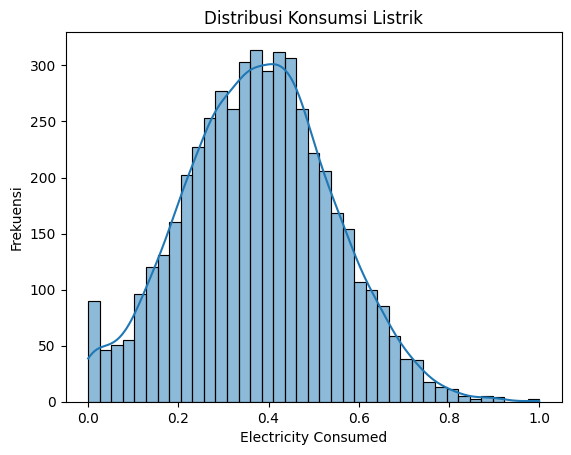

In [41]:
# Distribusi target
plt.figure()
sns.histplot(df['Electricity_Consumed'], kde=True)
plt.title("Distribusi Konsumsi Listrik")
plt.xlabel("Electricity Consumed")
plt.ylabel("Frekuensi")
plt.show()

#### Distribusi Konsumsi Listrik
Visualisasi ini digunakan untuk melihat sebaran data pada variabel target yaitu konsumsi listrik. Dengan adanya histogram dan kurva KDE, dapat diketahui apakah data berdistribusi normal, miring (skewed), atau memiliki pola tertentu.

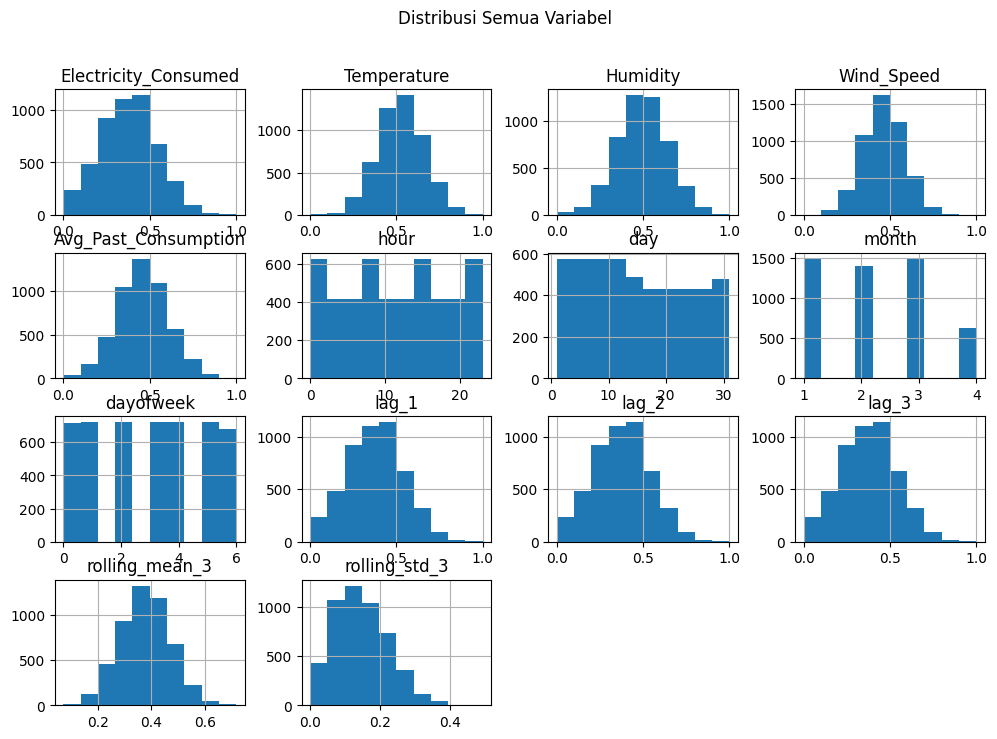

In [42]:
# Distribusi fitur lain (opsional biar lebih bagus)
df.hist(figsize=(12,8))
plt.suptitle("Distribusi Semua Variabel")
plt.show()

#### Distribusi Semua Variabel
Visualisasi ini menampilkan distribusi seluruh variabel dalam dataset. Tujuannya untuk memahami pola masing-masing fitur serta mendeteksi adanya keanehan seperti distribusi yang tidak normal atau nilai ekstrem.

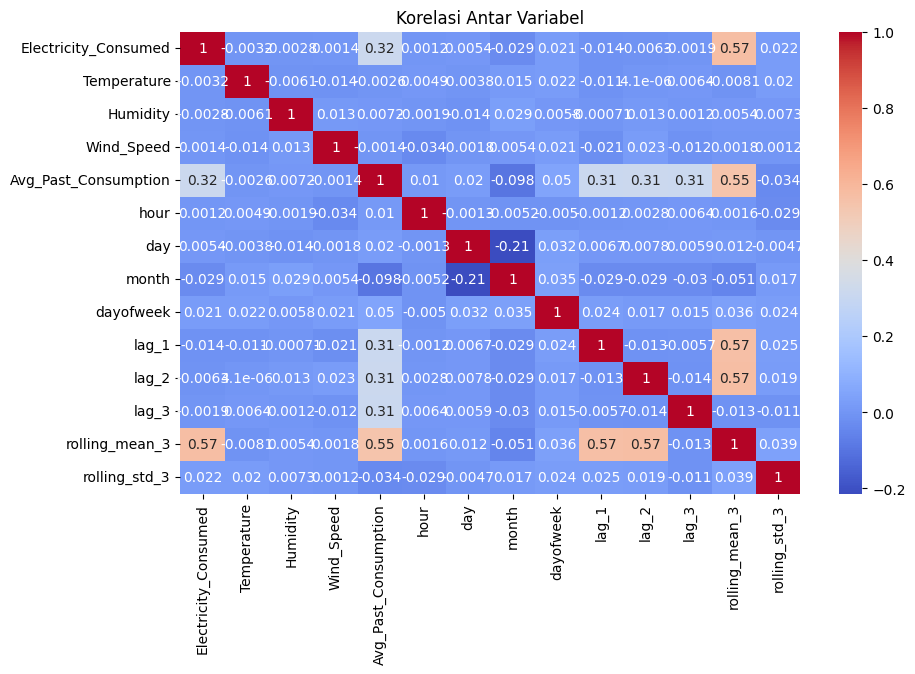

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Antar Variabel")
plt.show()

#### Korelasi Antar Variabel
Heatmap digunakan untuk melihat hubungan antar variabel dalam dataset. Nilai korelasi menunjukkan seberapa kuat hubungan antar fitur, sehingga dapat membantu dalam memilih fitur yang paling berpengaruh terhadap target.

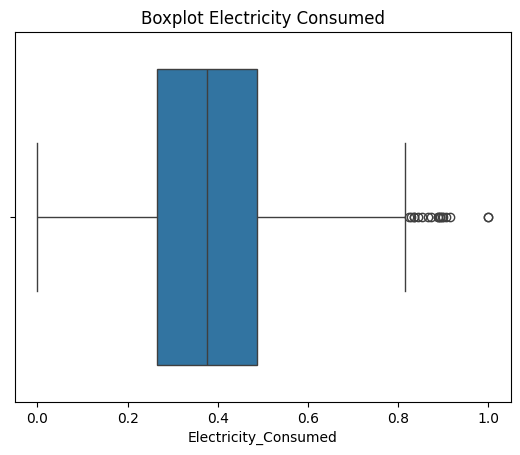

In [44]:
plt.figure()
sns.boxplot(x=df['Electricity_Consumed'])
plt.title("Boxplot Electricity Consumed")
plt.show()

#### Deteksi Outlier
Boxplot digunakan untuk mendeteksi adanya nilai ekstrem (outlier) pada data konsumsi listrik.

Namun, pada penelitian ini outlier tidak dihapus karena data bersifat time series, dimana setiap waktu dapat menghasilkan nilai konsumsi listrik yang berbeda-beda tergantung kondisi seperti temperatur, kelembapan, dan faktor lingkungan lainnya.

Nilai yang terlihat sebagai outlier kemungkinan merupakan kejadian nyata (real consumption spike), sehingga tetap dipertahankan agar model dapat mempelajari pola konsumsi listrik secara lebih akurat.

##**4. DATA SPLITTING (3 SKENARIO)**

In [45]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

for name, test_size in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, shuffle=False
    )

    print(f"Split {name}")
    print(f"Jumlah data train: {len(X_tr)}")
    print(f"Jumlah data test : {len(X_te)}")
    print("------------------------------")

Split 70:30
Jumlah data train: 3497
Jumlah data test : 1500
------------------------------
Split 80:20
Jumlah data train: 3997
Jumlah data test : 1000
------------------------------
Split 90:10
Jumlah data train: 4497
Jumlah data test : 500
------------------------------


#### Pembagian Data (Train-Test Split)
Pada tahap ini dilakukan pembagian dataset menjadi data latih (training) dan data uji (testing).

Dictionary `splits` digunakan untuk mendefinisikan beberapa skenario pembagian data, seperti 70:30, 80:20, dan 90:10, yang dapat digunakan untuk eksperimen lebih lanjut.

Namun, pada proses utama digunakan pembagian 80:20, dimana 80% data digunakan untuk pelatihan model dan 20% untuk pengujian.

Parameter `shuffle=False` digunakan karena data bersifat time series, sehingga urutan waktu harus dipertahankan agar model belajar dari data masa lalu untuk memprediksi data masa depan.

##**5. MODEL BUILDING**

In [46]:
# 5a. Random Forest Regressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Split data 80:20 (PAKAI X_SCALED)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# Model Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Training
rf.fit(X_train, y_train)

# Prediksi
pred_rf = rf.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, pred_rf)
mae = mean_absolute_error(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = np.sqrt(mse)

print("=== Random Forest (80:20 split) ===")
print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)

=== Random Forest (80:20 split) ===
R2   : 0.9709078923487325
MAE  : 0.019721985250727565
MSE  : 0.0007636314013258349
RMSE : 0.027633881401747294


#### Random Forest Regressor
Random Forest merupakan algoritma ensemble yang bekerja dengan membangun banyak decision tree dan menggabungkan hasil prediksinya.

Model dilatih menggunakan pembagian data 80% training dan 20% testing, kemudian dievaluasi menggunakan metrik R², MAE, MSE, dan RMSE.

Berdasarkan hasil evaluasi, Random Forest menghasilkan performa terbaik dengan nilai R² sebesar 0.97, yang menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data dengan tingkat error yang sangat kecil.

In [47]:
# 5b. Extra Trees Regressor
from sklearn.ensemble import ExtraTreesRegressor

# Model Extra Trees
et = ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42)

# Training
et.fit(X_train, y_train)

# Prediksi
pred_et = et.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, pred_et)
mae = mean_absolute_error(y_test, pred_et)
mse = mean_squared_error(y_test, pred_et)
rmse = np.sqrt(mse)

print("\n=== Extra Trees (80:20 split) ===")
print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


=== Extra Trees (80:20 split) ===
R2   : 0.9140367642250151
MAE  : 0.040396205549139794
MSE  : 0.0022564273095729034
RMSE : 0.04750186637988978


#### Extra Trees Regressor
Extra Trees adalah algoritma ensemble yang mirip dengan Random Forest, namun menggunakan pembentukan pohon yang lebih acak.

Model ini juga dilatih menggunakan pembagian data 80:20 dan dievaluasi dengan metrik yang sama.

Hasil menunjukkan nilai R² sebesar 0.91, yang berarti performanya cukup baik, namun masih di bawah Random Forest dalam memprediksi konsumsi listrik.

In [48]:
#5.c Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Model Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Training
gb.fit(X_train, y_train)

# Prediksi
pred_gb = gb.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, pred_gb)
mae = mean_absolute_error(y_test, pred_gb)
mse = mean_squared_error(y_test, pred_gb)
rmse = np.sqrt(mse)

print("\n=== Gradient Boosting (80:20 split) ===")
print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


=== Gradient Boosting (80:20 split) ===
R2   : 0.949128571688278
MAE  : 0.02531783498078337
MSE  : 0.0013353113000540717
RMSE : 0.03654191155446129


#### Gradient Boosting Regressor
Gradient Boosting merupakan metode ensemble yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya.

Dengan pembagian data 80:20, model ini menghasilkan nilai R² sebesar 0.94, yang menunjukkan performa yang cukup tinggi dalam menangkap pola data.

Meskipun akurasinya baik, performanya masih sedikit di bawah Random Forest.

##**6. HYPERPARAMETER TUNING**

In [49]:
# 6 a. Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ===============================
# PARAMETER TUNING
# ===============================
rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# ===============================
# GRID SEARCH
# ===============================
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Training
rf_grid.fit(X_train, y_train)

# Model terbaik
best_rf = rf_grid.best_estimator_

# Prediksi
pred_rf = best_rf.predict(X_test)

# ===============================
# EVALUASI
# ===============================
r2 = r2_score(y_test, pred_rf)
mae = mean_absolute_error(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = np.sqrt(mse)

# ===============================
# OUTPUT
# ===============================
print("=== Random Forest (After Tuning) ===")
print("Best Parameter :", rf_grid.best_params_)
print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)

=== Random Forest (After Tuning) ===
Best Parameter : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
R2   : 0.9737689970727
MAE  : 0.017835115032032806
MSE  : 0.0006885309845429297
RMSE : 0.0262398739429695


In [50]:
#6. b Extra Trees
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ===============================
# PARAMETER TUNING
# ===============================
et_param = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# ===============================
# GRID SEARCH
# ===============================
et_grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42),
    et_param,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Training
et_grid.fit(X_train, y_train)

# Model terbaik
best_et = et_grid.best_estimator_

# Prediksi
pred_et = best_et.predict(X_test)

# ===============================
# EVALUASI
# ===============================
r2 = r2_score(y_test, pred_et)
mae = mean_absolute_error(y_test, pred_et)
mse = mean_squared_error(y_test, pred_et)
rmse = np.sqrt(mse)

# ===============================
# OUTPUT
# ===============================
print("\n=== Extra Trees (After Tuning) ===")
print("Best Parameter :", et_grid.best_params_)
print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)


=== Extra Trees (After Tuning) ===
Best Parameter : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
R2   : 0.9802655531418113
MAE  : 0.015381257953973012
MSE  : 0.0005180045216851896
RMSE : 0.022759712688985984


In [51]:
# 6c. Gradient Boosting
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ===============================
# PARAMETER TUNING
# ===============================
gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# ===============================
# GRID SEARCH
# ===============================
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param, cv=3, scoring='r2', n_jobs=-1
)

# Training
gb_grid.fit(X_train, y_train)

# Model terbaik
best_gb = gb_grid.best_estimator_

# Prediksi
pred_gb = best_gb.predict(X_test)

# ===============================
# EVALUASI
# ===============================
r2 = r2_score(y_test, pred_gb)
mae = mean_absolute_error(y_test, pred_gb)
mse = mean_squared_error(y_test, pred_gb)
rmse = np.sqrt(mse)

# ===============================
# OUTPUT
# ===============================
print("\n=== Gradient Boosting (After Tuning) ===")
print("Best Parameter :", gb_grid.best_params_)
print("R2 :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)


=== Gradient Boosting (After Tuning) ===
Best Parameter : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
R2 : 0.9831325506785678
MAE : 0.014509193150119235
MSE : 0.00044274942594461973
RMSE : 0.021041611771549718


#### Hasil Hyperparameter Tuning
Setelah dilakukan hyperparameter tuning menggunakan GridSearchCV, performa seluruh model mengalami peningkatan dibandingkan sebelum tuning.

Random Forest menghasilkan nilai R² sebesar 0.973, menunjukkan performa yang sangat baik dalam memprediksi konsumsi listrik.

Extra Trees mengalami peningkatan yang signifikan dengan nilai R² sebesar 0.980, yang berarti model mampu menangkap pola data dengan lebih baik.

Gradient Boosting menjadi model terbaik dengan nilai R² sebesar 0.983 serta memiliki nilai error paling kecil dibandingkan model lainnya.

Hal ini menunjukkan bahwa proses tuning berhasil mengoptimalkan parameter model sehingga meningkatkan akurasi prediksi.

##**7. Model Evaluation**

In [52]:
# =========================
# MODEL EVALUATION
# =========================

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# =========================
# FUNCTION EVALUATION
# =========================
def evaluate(model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)

    return r2, mae, mse, rmse

# =========================
# MODEL DEFINISI
# =========================
rf_model = RandomForestRegressor(random_state=42)
et_model = ExtraTreesRegressor(random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

# =========================
# TRAIN MODEL (PAKAI X_SCALED)
# =========================
rf_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# =========================
# EVALUASI
# =========================
hasil = []

# Random Forest
r2_rf, mae_rf, mse_rf, rmse_rf = evaluate(rf_model, X_train, X_test, y_train, y_test)
hasil.append({
    "Model": "Random Forest",
    "R2": r2_rf,
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf
})

# Extra Trees
r2_etr, mae_etr, mse_etr, rmse_etr = evaluate(et_model, X_train, X_test, y_train, y_test)
hasil.append({
    "Model": "Extra Trees",
    "R2": r2_etr,
    "MAE": mae_etr,
    "MSE": mse_etr,
    "RMSE": rmse_etr
})

# Gradient Boosting
r2_gb, mae_gb, mse_gb, rmse_gb = evaluate(gb_model, X_train, X_test, y_train, y_test)
hasil.append({
    "Model": "Gradient Boosting",
    "R2": r2_gb,
    "MAE": mae_gb,
    "MSE": mse_gb,
    "RMSE": rmse_gb
})

# =========================
# DATAFRAME HASIL
# =========================
df_hasil = pd.DataFrame(hasil)
df_hasil = df_hasil.sort_values(by="R2", ascending=False)

print("=== HASIL MODEL EVALUATION (FINAL) ===")
print(df_hasil)

=== HASIL MODEL EVALUATION (FINAL) ===
               Model        R2       MAE       MSE      RMSE
1        Extra Trees  0.979131  0.015892  0.000548  0.023405
0      Random Forest  0.973929  0.017899  0.000684  0.026160
2  Gradient Boosting  0.949129  0.025318  0.001335  0.036542


#### Hasil Model Evaluation
Berdasarkan hasil evaluasi, model Extra Trees memiliki performa terbaik dengan nilai R² sebesar 0.979 serta error yang paling kecil dibandingkan model lainnya.

Random Forest juga menunjukkan performa yang sangat baik dengan nilai R² sebesar 0.973.

Sementara itu, Gradient Boosting memiliki performa yang cukup baik, namun masih berada di bawah kedua model lainnya.

Hasil ini menunjukkan bahwa model Extra Trees lebih optimal dalam memprediksi konsumsi listrik pada dataset yang digunakan.

##**8. Model Comparison**

               Model  Split        R2       MAE      RMSE
1        Extra Trees  70:30  0.973745  0.017599  0.026383
4        Extra Trees  80:20  0.977767  0.016412  0.024572
7        Extra Trees  90:10  0.979277  0.015686  0.024029
2  Gradient Boosting  70:30  0.945687  0.027397  0.037946
5  Gradient Boosting  80:20  0.942186  0.028422  0.039624
8  Gradient Boosting  90:10  0.943012  0.028006  0.039848
0      Random Forest  70:30  0.961163  0.020703  0.032088
3      Random Forest  80:20  0.966034  0.020533  0.030371
6      Random Forest  90:10  0.966962  0.019514  0.030341


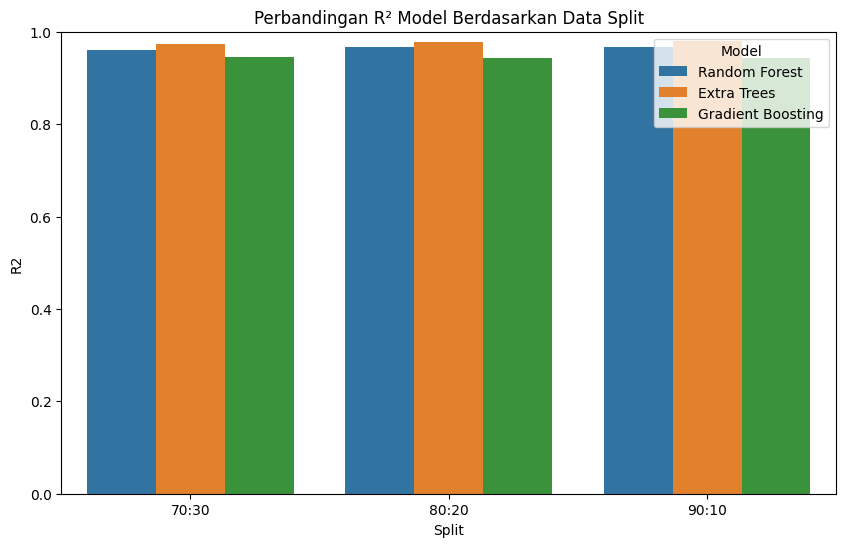

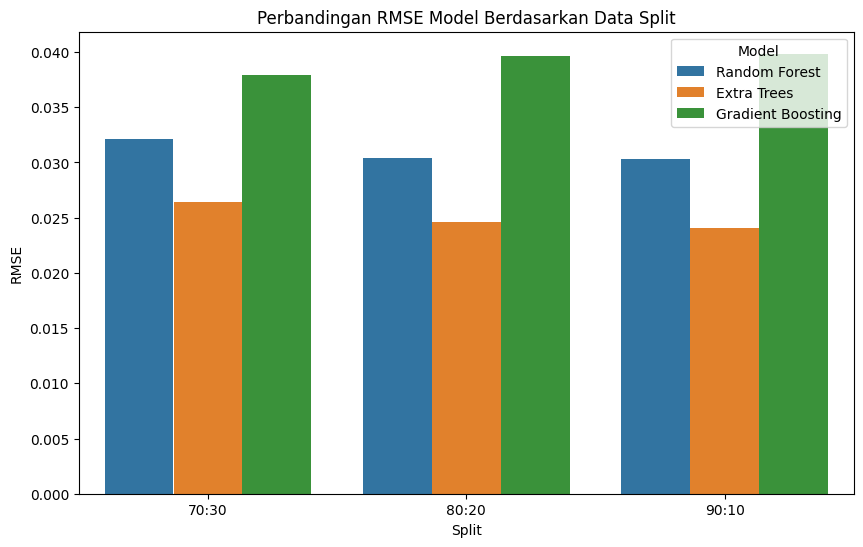

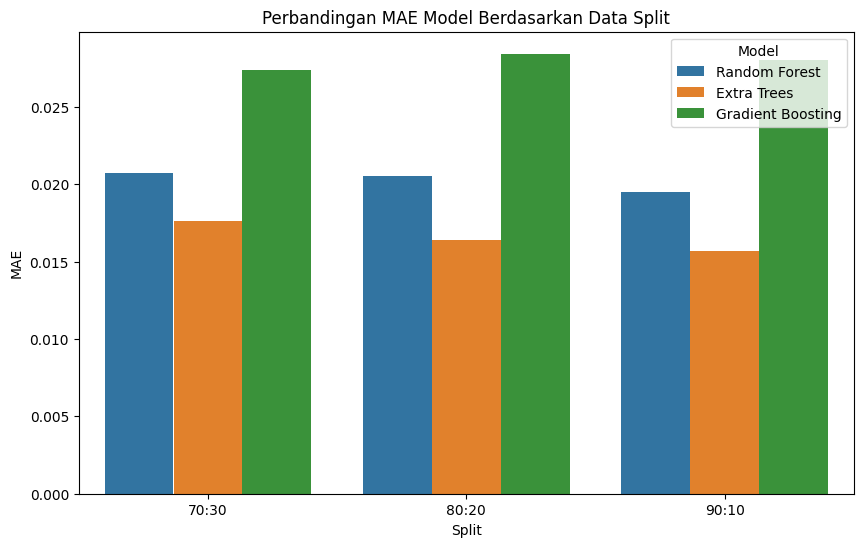


=== BEST MODEL ===
Model    Extra Trees
Split          90:10
R2          0.979277
MAE         0.015686
RMSE        0.024029
Name: 7, dtype: object


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# DATA SPLIT
# =========================
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

# =========================
# MODELS
# =========================
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# =========================
# STORAGE
# =========================
results = []

# =========================
# TRAINING + EVALUATION
# =========================
for split_name, test_size in splits.items():

    # 🔥 PERBAIKAN DI SINI (pakai X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Split": split_name,
            "R2": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
        })

# =========================
# DATAFRAME
# =========================
df_result = pd.DataFrame(results)

print(df_result.sort_values(["Model", "Split"]))

# =========================
# 📊 BARPLOT R2
# =========================
plt.figure(figsize=(10,6))
sns.barplot(data=df_result, x="Split", y="R2", hue="Model")
plt.title("Perbandingan R² Model Berdasarkan Data Split")
plt.ylim(0, 1)
plt.show()

# =========================
# 📊 BARPLOT RMSE
# =========================
plt.figure(figsize=(10,6))
sns.barplot(data=df_result, x="Split", y="RMSE", hue="Model")
plt.title("Perbandingan RMSE Model Berdasarkan Data Split")
plt.show()

# =========================
# 📊 BARPLOT MAE
# =========================
plt.figure(figsize=(10,6))
sns.barplot(data=df_result, x="Split", y="MAE", hue="Model")
plt.title("Perbandingan MAE Model Berdasarkan Data Split")
plt.show()

# =========================
# 🏆 BEST MODEL
# =========================
best_model = df_result.loc[df_result["R2"].idxmax()]

print("\n=== BEST MODEL ===")
print(best_model)

#### Model Comparison

Pada tahap ini dilakukan perbandingan performa tiga model, yaitu Random Forest, Extra Trees, dan Gradient Boosting dengan tiga skenario pembagian data: 70:30, 80:20, dan 90:10.

Setiap model dilatih dan diuji pada masing-masing skenario split, kemudian dievaluasi menggunakan metrik R², MAE, dan RMSE.

Berdasarkan hasil perbandingan, model Extra Trees menunjukkan performa terbaik dan paling konsisten pada berbagai skenario pembagian data, dengan nilai R² yang paling tinggi serta error yang lebih rendah dibandingkan model lainnya.

Hal ini menunjukkan bahwa model Extra Trees lebih optimal dalam menangkap pola data untuk prediksi konsumsi energi pada penelitian ini.

In [54]:
# Cross Validation
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

def cross_val_model(model, X, y, nama):
    tscv = TimeSeriesSplit(n_splits=5)

    scores = cross_val_score(model, X, y, cv=tscv, scoring='r2')

    print(f"\n=== {nama} Time Series CV ===")
    print("Scores:", np.round(scores, 5))
    print("Mean  :", round(np.mean(scores), 5))
    print("Std   :", round(np.std(scores), 5))

    # interpretasi sederhana
    if np.std(scores) > 0.05:
        print("⚠️ model kurang stabil (indikasi overfitting)")
    else:
        print("✔ model stabil")

# jalankan untuk semua model
cross_val_model(rf_model, X, y, "Random Forest")
cross_val_model(et_model, X, y, "Extra Trees")
cross_val_model(gb_model, X, y, "Gradient Boosting")


=== Random Forest Time Series CV ===
Scores: [0.87094 0.94342 0.95441 0.96038 0.9744 ]
Mean  : 0.94071
Std   : 0.03629
✔ model stabil

=== Extra Trees Time Series CV ===
Scores: [0.90347 0.95772 0.96624 0.9691  0.98022]
Mean  : 0.95535
Std   : 0.02692
✔ model stabil

=== Gradient Boosting Time Series CV ===
Scores: [0.9096  0.9399  0.93727 0.94333 0.95091]
Mean  : 0.9362
Std   : 0.01407
✔ model stabil


MEMPREDIKSI DATA BARU


In [55]:
import pandas as pd
import numpy as np

# 🔥 Data terakhir (WAJIB ADA 3)
last_3_consumption = [120, 130, 125]  # lama → terbaru

# 🔥 Data kondisi ke depan (3 waktu)
data_future = pd.DataFrame({
    'Temperature': [30, 31, 32],
    'Humidity': [70, 68, 65],
    'Wind_Speed': [5, 4, 6],
    'Timestamp': [
        '2024-06-01 14:00:00',
        '2024-06-01 14:30:00',
        '2024-06-01 15:00:00'
    ]
})

# 🔥 Konversi waktu
data_future['Timestamp'] = pd.to_datetime(data_future['Timestamp'])

# Feature waktu
data_future['hour'] = data_future['Timestamp'].dt.hour
data_future['day'] = data_future['Timestamp'].dt.day
data_future['month'] = data_future['Timestamp'].dt.month
data_future['dayofweek'] = data_future['Timestamp'].dt.dayofweek

# 🔥 List hasil prediksi
predictions = []

# 🔥 Loop prediksi berurutan
for i in range(len(data_future)):

    # Ambil data ke-i
    row = data_future.iloc[i:i+1].copy()

    # 🔥 Tambahkan lag
    row['lag_1'] = last_3_consumption[-1]
    row['lag_2'] = last_3_consumption[-2]
    row['lag_3'] = last_3_consumption[-3]

    # 🔥 Tambahkan rolling
    row['rolling_mean_3'] = np.mean(last_3_consumption)
    row['rolling_std_3'] = np.std(last_3_consumption)

    # 🔥 PERBAIKAN UTAMA (WAJIB ADA)
    row['Avg_Past_Consumption'] = np.mean(last_3_consumption)

    # 🔥 Ambil fitur (AMAN)
    X_baru = row[[
        'Temperature',
        'Humidity',
        'Wind_Speed',
        'Avg_Past_Consumption',
        'hour',
        'day',
        'month',
        'dayofweek',
        'lag_1',
        'lag_2',
        'lag_3',
        'rolling_mean_3',
        'rolling_std_3'
    ]]

    # 🔥 Prediksi
    pred = model.predict(X_baru)[0]

    # 🔥 Simpan hasil
    predictions.append(pred)

    # 🔥 Update lag (GESER DATA)
    last_3_consumption.append(pred)
    last_3_consumption.pop(0)

# 🔥 Tampilkan hasil
for i, p in enumerate(predictions):
    print(f"Prediksi ke-{i+1}: {p}")

Prediksi ke-1: 0.3598948202509066
Prediksi ke-2: 0.5928641451491506
Prediksi ke-3: 0.8021102417670369


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [56]:
import joblib

# Simpan model terbaik
joblib.dump(best_et, 'best_model_extra_trees.pkl')

print("Model Extra Trees berhasil disimpan!")

Model Extra Trees berhasil disimpan!


In [57]:
from joblib import dump

dump(scaler, "scaler.pkl")

['scaler.pkl']

In [58]:
from google.colab import files
files.download('best_model_extra_trees.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>